# Imports

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from difflib import SequenceMatcher

In [2]:
authors = pd.read_csv("/Users/imogennagle/Desktop/UChicago/Capstone/authors.csv")
authors.head()

,source_file,id,paper_title,ppt_title,paper_authors,ppt_authors
0,acl17.pkl,216,Towards String-to-Tree Neural Machine Translation,Towards String-to-Tree,Roee Aharoni,Roee Aharoni
1,acl17.pkl,48,Found in Translation: Reconstructing Phylogene...,Reconstructing Phylogenetic Language Trees,Ella RabinovichM; Noam Ordan; Shuly Wintner,Ella RabinovichM; Noam Ordan; Shuly Wintner
2,acl17.pkl,65,Detect Rumors in Microblog Posts Using Propaga...,Detect Rumors in Microblog Posts Using,Jing Ma; Wei Gao; Kam-Fai Wong,Jing Mal; Wei Ga02* Kam-Fai Wong1'3
3,acl17.pkl,210,On the Challenges of Translating NLP Research ...,Commercial Products,Daniel Dahlmeier,Daniel Dahlmeier
4,acl17.pkl,60,Learning Discourse-level Diversity for Neural ...,Learning Discourse-level Diversity for,Tiancheng Zhao; Ran Zhao; Maxine Eskenazi,Tiancheng Zhao; Ran Zhao and Maxine Eskenazi


In [3]:
len(authors)

5873

# Identifying the number of paper-ppt pairs for each author

Cleaning the names after parsing

In [27]:
def clean_name(name):
    if pd.isna(name):
        return ""
    name = name.lower().strip()

    #remove digits and odd symbols
    name = re.sub(r"\d+", "", name)
    name = re.sub(r"[^a-z\s\-]", "", name)

    #normalize spacing
    name = re.sub(r"\s+", " ", name).strip()

    return name

In [4]:
def split_authors(s):
    if pd.isna(s):
        return set()
    return {
        a.strip()
        for a in s.replace(" and ", ";").split(";")
        if a.strip()
    }

Fuzzy match authors within a row

In [28]:
def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

def authors_match(a, b, threshold=0.8):
    a_clean = clean_name(a)
    b_clean = clean_name(b)
    return similar(a_clean, b_clean) >= threshold

Finding author matches for paper-ppt

In [29]:
def matched_authors_fuzzy(paper_authors, ppt_authors, threshold=0.8):
    paper_list = split_authors(paper_authors)
    ppt_list = split_authors(ppt_authors)

    matches = []
    used_ppt = set()

    for p in paper_list:
        best_match = None
        best_score = 0

        for j, q in enumerate(ppt_list):
            if j in used_ppt:
                continue

            score = similar(clean_name(p), clean_name(q))
            if score > best_score:
                best_score = score
                best_match = j

        if best_match is not None and best_score >= threshold:
            matches.append(p)   #keep canonical paper-side name
            used_ppt.add(best_match)

    return matches

In [30]:
authors["matched_authors"] = authors.apply(
    lambda row: matched_authors_fuzzy(row["paper_authors"], row["ppt_authors"], threshold=0.8),
    axis=1
)

In [31]:
df_matched = authors.explode("matched_authors").dropna(subset=["matched_authors"])

In [32]:
author_pair_counts = df_matched["matched_authors"].value_counts()
author_pair_counts.head()

matched_authors
Qi Tian          29
Sergey Levine    24
Luc Van Gool     24
Dacheng Tao      23
Ling Shao        22
Name: count, dtype: int64

Finding the number of authors that have written at least 3 paper-ppt pairs

In [40]:
print((author_pair_counts >= 3).sum())

1669


Table for number of papers out for each author

In [42]:
counts_table = {
    k: (author_pair_counts >= k).sum()
    for k in range(1, 11)
}

In [44]:
counts_df = pd.DataFrame.from_dict(counts_table, orient="index", columns=["num_authors"])
counts_df.index.name = "min_pairs"

print(counts_df)

           num_authors
min_pairs             
1                14274
2                 3860
3                 1669
4                  886
5                  527
6                  328
7                  210
8                  140
9                  103
10                  82


Histogram of paper-ppt pairs for authors

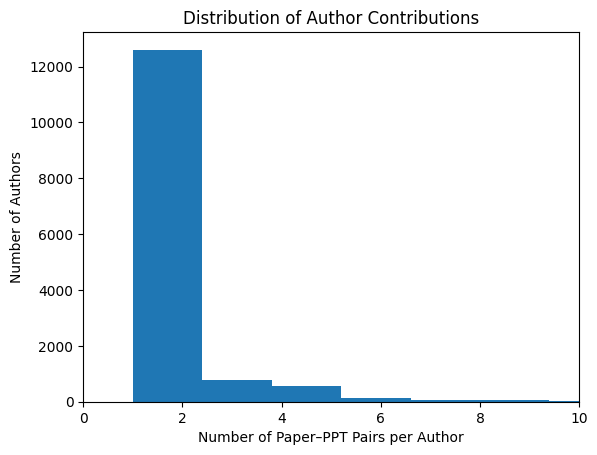

In [41]:
plt.figure()
plt.hist(author_pair_counts, bins=20)
#plt.xlim(0, 10)
plt.xlabel("Number of Paper–PPT Pairs per Author")
plt.ylabel("Number of Authors")
plt.title("Distribution of Author Contributions")
plt.show()

# Examining some of the files

In [23]:
pd.set_option('display.max_colwidth', None)
data = pd.read_pickle("/Users/imogennagle/Desktop/UChicago/v1.0/acl17.pkl")
df = pd.DataFrame(data)

df.head(1)

idd  \
0  216   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              